In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import datetime as dt
from pathlib import Path



In [2]:
def extract_Ap(Ap_file):

    full_data_df = pd.read_csv(filepath_or_buffer='raw_data/' + Ap_file,
                               sep=r'\s+',
                               skiprows=39)
    
    year_mm_dd = full_data_df[['#YYY', 'MM', 'DD']].copy()

    year_mm_dd = year_mm_dd.rename(columns={'#YYY': 'year', 'MM': 'month', 'DD': 'day'})

    dates = pd.to_datetime(year_mm_dd)
    
    Ap_df = pd.DataFrame({'Datetime': dates, 'Ap': full_data_df['Ap']})

    # Add thing to deal with bad Ap values

    #Ap_df.to_csv('Ap.csv', index=False)

    return Ap_df

In [3]:
Ap_file = 'Kp_ap_Ap_SN_F107_since_1932.txt'

Ap_df = extract_Ap(Ap_file=Ap_file)

print(Ap_df)

        Datetime  Ap
0     1932-01-01  15
1     1932-01-02  26
2     1932-01-03  11
3     1932-01-04   4
4     1932-01-05   3
...          ...  ..
34286 2025-11-14   3
34287 2025-11-15   8
34288 2025-11-16  16
34289 2025-11-17  10
34290 2025-11-18   4

[34291 rows x 2 columns]


In [4]:
bad_indicies = Ap_df.index[Ap_df['Ap'] == -1.0]
print(bad_indicies)

Index([], dtype='int64')


In [5]:
print(min(Ap_df['Ap']))

0


In [ ]:
def count_files(directory):
    """
    Counts the number of files in a directory.
    
    Parameters
    ----------
    directory: str
        Directory to count files within.
    
    Returns
    -------
    count: list
        Unsorted list containing names of all files in directory as strings.
    """
    
    dir_path = Path(directory)

    count = len([p for p in dir_path.iterdir() if p.is_file()])
    
    return count


def get_file_dates(report_name):
    """
    Finds all files in a directory and trims file name strings so that only date of file remains.
    
    Parameters
    ----------
    report_name: str
        Name of the report to study. One of 'daypre', 'geomag_forecast', 'rsga', 'the_weekly', 'three_day_forecast'
    
    Returns
    -------
    list_files: list
        Unsorted list containing all trimed string with date information of file.
    """

    dir_path = Path(f'raw_data/{report_name}')

    if report_name == 'daypre' or report_name == 'geomag_forecast' or report_name == 'rsga':
        last_ind = 8
    if report_name == 'three_day_forecast':
        last_ind = 12

    list_files = [p.name[:last_ind] for p in dir_path.iterdir() if p.is_file()]

    return list_files


def file_names_to_datetimes(list_files, report_name):
    """
    Converts list of files with trimmed string to list of datetimes corresponding with file date.
    
    Parameters
    ----------
    list_files: list
        List of trimmed string containing date information of files for the report.
    report_name: str
        Name of the report to study. One of 'daypre', 'geomag_forecast', 'rsga', 'the_weekly', 'three_day_forecast'
    
    Returns
    -------
    dt_list_files: list
        Sorted list (oldest to newest) of dates/datetimes corresponding to the files for the report.
    """

    if report_name == 'daypre' or report_name == 'geomag_forecast' or report_name == 'rsga':
        date_format = [dt.date(year=int(p[0:4]), month=int(p[4:6]), day=int(p[6:8])) for p in list_files]
    if report_name == 'three_day_forecast':
        date_format = [dt.datetime(year=int(p[0:4]), month=int(p[4:6]), day=int(p[6:8]), hour=int(p[8:10]), minute=int(p[10:12])) for p in list_files]

    dt_list_files = sorted(date_format)

    return dt_list_files


def generate_date_range(dt_list_files, report_name):
    """
    Generates list of all dates between oldest and newest file for the report.
    
    Parameters
    ----------
    dt_list_files: list
        Sorted list (oldest to newest) of dates/datetimes corresponding to the files for the report.
    report_name: str
        Name of the report to study. One of 'daypre', 'geomag_forecast', 'rsga', 'the_weekly', 'three_day_forecast'
    
    Returns
    -------
    full_datetime_range: list
        Sorted list (oldest to newest) of all dates/datetimes between oldest and newest file for the report.
    """

    start_date = dt_list_files[0]
    end_date = dt_list_files[-1]

    if report_name == 'daypre' or report_name == 'geomag_forecast' or report_name == 'rsga':
        freq = '1d'
    if report_name == 'three_day_forecast':
        freq = '12h'
    if report_name == 'the_weekly':
        freq = '1W'

    full_datetime_range = pd.date_range(start=start_date,
                                        end=end_date,
                                        freq=freq).to_pydatetime().tolist()
    
    if report_name == 'daypre' or report_name == 'geomag_forecast' or report_name == 'the_weekly' or report_name == 'rsga':
        return [d.date() for d in full_datetime_range]
    if report_name == 'three_day_forecast':
        return full_datetime_range


def generate_date_mask(dt_list_files, full_date_range):
    """
    Generates list that masks full_date_range s.t. missing files are 0 and existing files are 1
    
    Parameters
    ----------
    dt_list_files: list
        Sorted list (oldest to newest) of dates/datetimes corresponding to the files for the report.
    full_date_range: list
        Sorted list (oldest to newest) of all dates/datetimes between oldest and newest file for the report.
    
    Returns
    -------
    date_ints: list
        List that masks full_date_range s.t. missing files are 0 and existing files are 1
    """

    date_mask = []
    for i in range(len(full_date_range)):
        date_mask.append(full_date_range[i] in dt_list_files)

    date_ints = [int(i) for i in date_mask]

    return date_ints


def count_missing_reports(date_ints):
    """
    Generates list that masks full_date_range s.t. missing files are 0 and existing files are 1
    
    Parameters
    ----------
    date_ints: list
        List that masks full_date_range s.t. missing files are 0 and existing files are 1
    
    Returns
    -------
    total: int
        Number of files of a given report type
    missing: int
        Number of files missing between start and end date of a report.
    
    """

    total = len(date_ints)
    missing = int(date_ints.count(0))

    return total, missing

def reshape_mask(date_ints, width):
    """
    Reshapes date mask to 2d. Appends blank elements as needed.

    Parameters
    ----------
    date_ints: list
        List that masks full_date_range s.t. missing files are 0, and existing files are 1
    width: int
        Number of files represented in each row of the plot.
    
    Returns
    -------
    date_ints_2d: numpy.ndarry (n, width)
        2d date mask s.t. missing files are 0, existing files are 1, and extra dates needed for reshaping are -1
    """
    while len(date_ints) % width != 0:
        date_ints.append(-1)

    date_ints_2d = np.reshape(date_ints, (-1, width))

    return date_ints_2d


def create_color_map():
    """
    Creates color map for calander plot of missing reports. Missing is colored red and existing is colored green
    
    Returns
    -------
    cmap: matplotlib.colors.ListedColormap
        color map for calander plot of missing reports. Missing is colored red and existing is colored green
    """

    calander_cmap = mcolors.ListedColormap(['white', 'firebrick', 'forestgreen'])

    return calander_cmap


def create_daily_calander_plot(report_name, start_date=None, end_date=None, width=60):
    """
    Generates calander plot of files of a report. Red is missing, green exists.
    
    Parameters
    ----------
    report_name: str
        Name of the report to study. One of 'daypre', 'geomag_forecast', 'rsga', 'the_weekly', 'three_day_forecast'
    start_date: (dt.date | dt.datetime), optional
        Date to begin analysis. If None conducts analysis from the first file avilable. Default is None
    end_date: (dt.date | dt.datetime), optional
        Date to stop analysis. If None conducts analysis until the last avilable file. Default is None
    width: int, optional
        Number of files represented in each row of the plot. Default is 60.
    
    Returns
    -------
    None
        Displays and saves plot directly.
    """

    # Generate image array
    raw_list_files = get_file_dates(report_name)
    dt_list_files = file_names_to_datetimes(raw_list_files, report_name)
    full_date_range = generate_date_range(dt_list_files, report_name)
    date_ints = generate_date_mask(dt_list_files, full_date_range)

    if start_date is not None and end_date is None:
        start_ind = full_date_range.index(start_date)
        full_date_range = full_date_range[start_ind:]
        date_ints = date_ints[start_ind:]
    elif start_date is None and end_date is not None:
        end_ind = full_date_range.index(end_date)
        full_date_range = full_date_range[:end_ind+1]
        date_ints = date_ints[:end_ind+1]
    elif start_date is not None and end_date is not None:
        start_ind = full_date_range.index(start_date)
        end_ind = full_date_range.index(end_date)
        full_date_range = full_date_range[start_ind:end_ind+1]
        date_ints = date_ints[start_ind:end_ind+1]
    
    date_ints_2d = reshape_mask(date_ints, width)

    # Initialize figure
    cell_size = 0.2
    fig_width = width * cell_size
    fig_height = date_ints_2d.shape[0] * cell_size

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Create visual background grid
    ax.set_xticks(np.arange(-0.5, date_ints_2d.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, date_ints_2d.shape[0], 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=4*cell_size)
    ax.tick_params(which='minor', bottom=False, left=False)

    # Configure ticks
    ax.set_xticks([-0.5, width - 0.5], labels=[0, width])
    ax.set_yticks([-0.5, date_ints_2d.shape[0] - 0.5], labels=[full_date_range[0], full_date_range[-1]])
    ax.tick_params(axis='both', which='major', direction='out', labelsize=100*cell_size)

    # Set titles
    total, missing = count_missing_reports(date_ints)

    if report_name == 'daypre':
        title = f'3-Day Space Weather Prediction: 1/2/3-day Ap forecast, {(missing/total)*100:.2f}% Missing'
    if report_name == 'geomag_forecast':
        title = f'3-Day Geomagnetic Forecast: 3-day/3-hr Kp forecast, 1/2/3-day Ap forecast, 1/2/3-day Probabalistic Geomagnetic Storm Forecast, {(missing/total)*100:.2f}% Missing'
    if report_name == 'three_day_forecast':
        title = f'3-Day Forecast:  3-day/3-hr Kp forecast, {(missing/total)*100:.2f}% Missing'
    if report_name == 'rsga':
        title = f'RSGA: 1/2/3-day F10.7cm forecast, {(missing/total)*100:.2f}% Missing'
    
    title_font_size = 1.4*fig_width

    ax.set_title(title, fontsize=title_font_size, pad=20)

    # Use Patches to create legend
    legend_elements = [mpatches.Patch(color='forestgreen', label='Exists'),
                       mpatches.Patch(color='firebrick', label='Missing')]
    #ax.legend(handles=legend_elements, fontsize=1.5*fig_size)

    calander_cmap = create_color_map()
    im = plt.imshow(date_ints_2d, cmap=calander_cmap)
    
    fig.savefig(f'analysis/{report_name}_calander.png', bbox_inches='tight', facecolor='white')
    plt.show()

    return


def make_all_calanders(daypre_start_date=None, geomag_forecast_start_date=None, three_day_forecast_start_date=None, rsga_start_date=None, daypre_end_date=None, geomag_forecast_end_date=None, three_day_forecast_end_date=None, rsga_end_date=None):
    """
    Generates calander plots for report types 'daypre', 'geomag_forecast', 'rsga', 'the_weekly', 'three_day_forecast'
    
    Returns
    -------
    None
        Displays and saves plots directly.
    """

    create_daily_calander_plot(report_name='daypre', start_date=daypre_start_date, end_date=daypre_end_date)
    create_daily_calander_plot(report_name='geomag_forecast', start_date=geomag_forecast_start_date, end_date=geomag_forecast_end_date)
    create_daily_calander_plot(report_name='three_day_forecast', start_date=three_day_forecast_start_date, end_date=three_day_forecast_end_date)
    create_daily_calander_plot(report_name='rsga', start_date=rsga_start_date, end_date=rsga_end_date)

    return




In [7]:
report_name = 'three_day_forecast'
start_date = dt.datetime(2022, 3, 25, 12, 30)
end_date = dt.datetime(2022, 3, 26, 12, 30)
raw_list_files = get_file_dates(report_name)
dt_list_files = file_names_to_datetimes(raw_list_files, report_name)
print(dt_list_files)

[datetime.datetime(2022, 3, 25, 0, 30), datetime.datetime(2022, 3, 25, 12, 30), datetime.datetime(2022, 3, 26, 0, 30), datetime.datetime(2022, 3, 26, 12, 30), datetime.datetime(2022, 3, 27, 0, 30), datetime.datetime(2022, 3, 27, 12, 30), datetime.datetime(2022, 3, 28, 0, 30), datetime.datetime(2022, 3, 28, 12, 30), datetime.datetime(2022, 3, 29, 0, 30), datetime.datetime(2022, 3, 29, 12, 30), datetime.datetime(2022, 3, 30, 0, 30), datetime.datetime(2022, 3, 30, 12, 30), datetime.datetime(2022, 3, 31, 0, 30), datetime.datetime(2022, 3, 31, 12, 30), datetime.datetime(2022, 4, 1, 0, 30), datetime.datetime(2022, 4, 1, 12, 30), datetime.datetime(2022, 4, 2, 0, 30), datetime.datetime(2022, 4, 2, 12, 30), datetime.datetime(2022, 4, 3, 0, 30), datetime.datetime(2022, 4, 3, 12, 30), datetime.datetime(2022, 4, 4, 0, 30), datetime.datetime(2022, 4, 4, 12, 30), datetime.datetime(2022, 4, 5, 0, 30), datetime.datetime(2022, 4, 5, 12, 30), datetime.datetime(2022, 4, 6, 0, 30), datetime.datetime(2022,

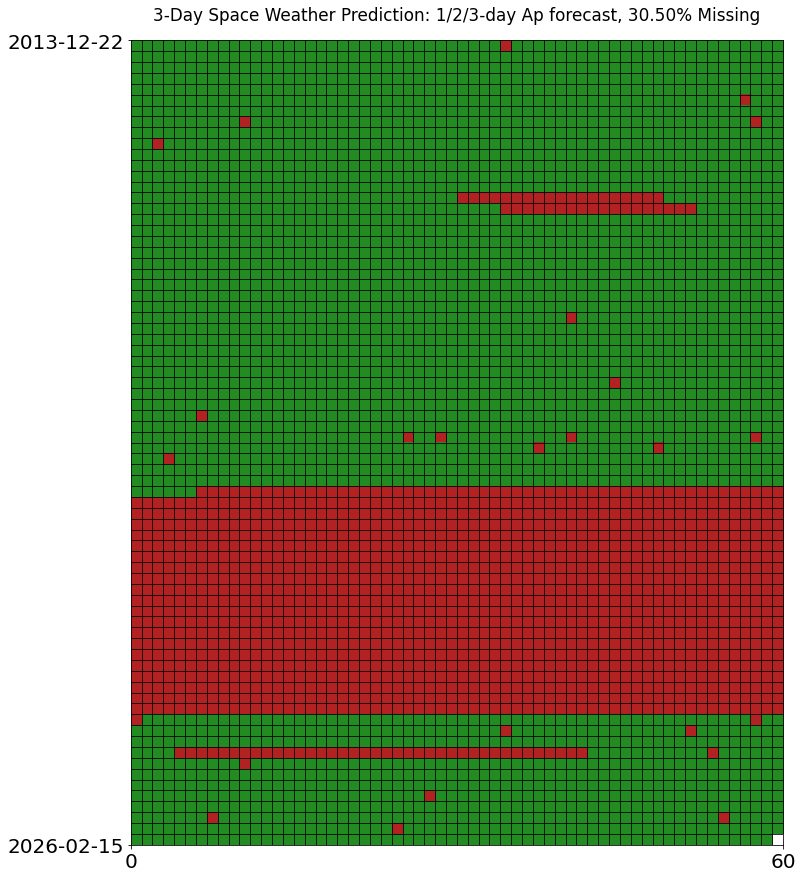

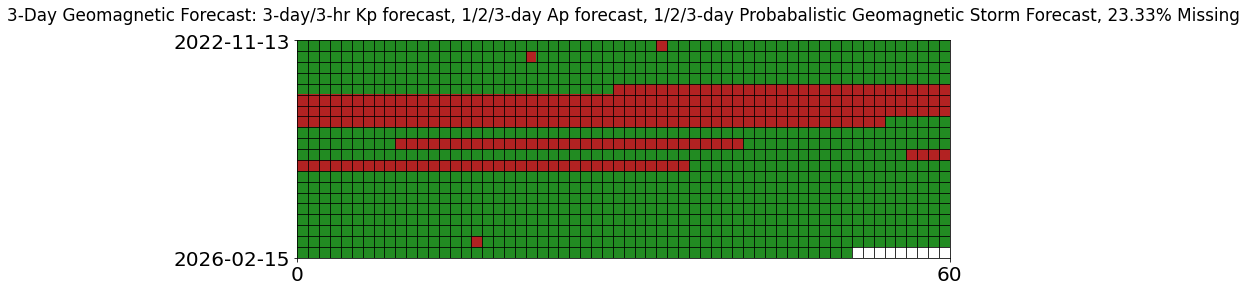

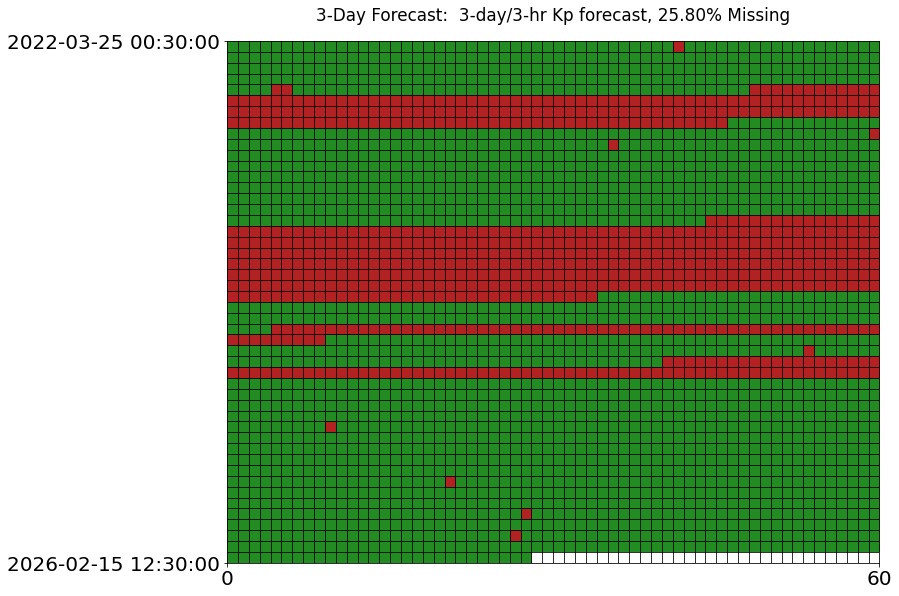

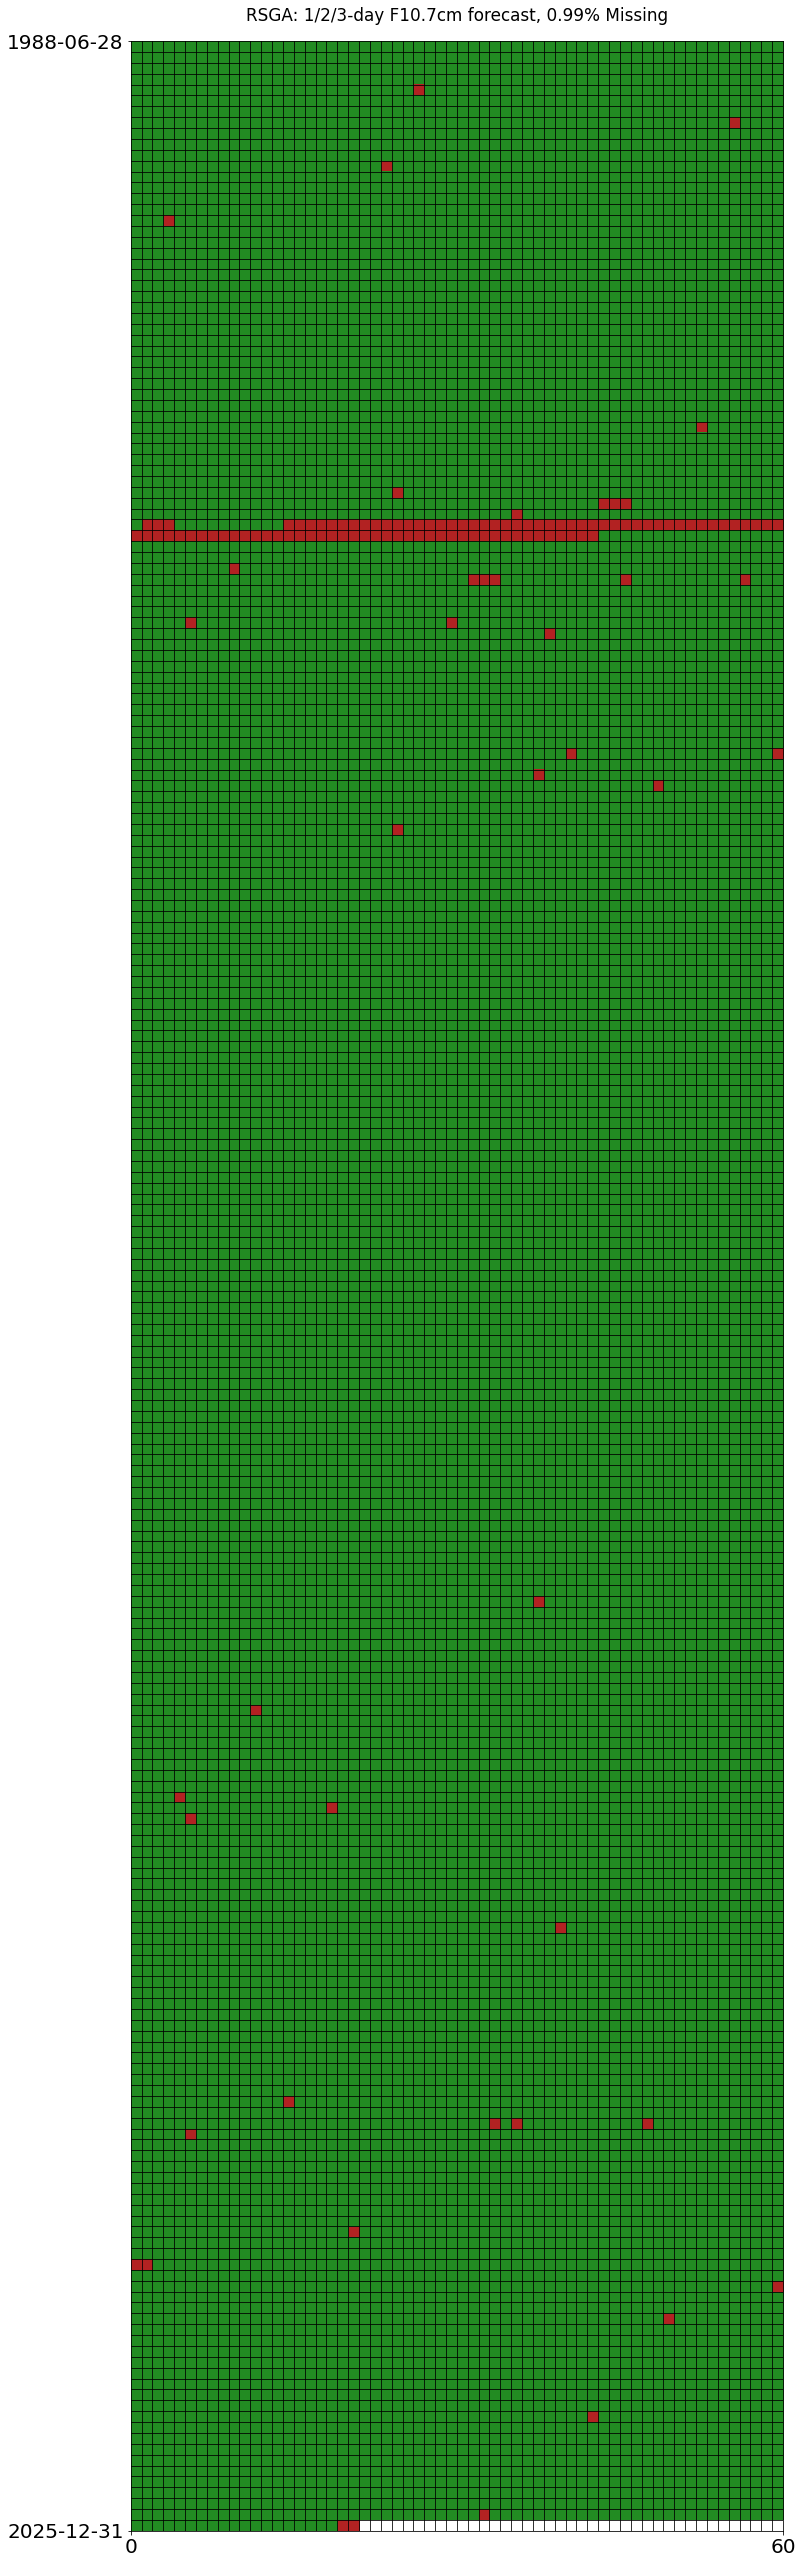

In [8]:
rsga_start_date = dt.date(1988, 6, 28)
rsga_end_date = dt.date(2025, 12, 31)
make_all_calanders(rsga_start_date=rsga_start_date, rsga_end_date=rsga_end_date)

### Check Number of the_weekly Files

In [9]:
dt_list_weekly = [dt.date(1997, 6, 2), dt.date(2026, 2, 9)]
full_date_range = generate_date_range(dt_list_files=dt_list_weekly, report_name='the_weekly')
num_weeks = len(full_date_range)
num_files = count_files(directory='raw_data/the_weekly')

print(f'Number of weeks {num_weeks}, number of files {num_files}')


Number of weeks 1497, number of files 1497


### Extract Data From Reports

In [10]:
# Extract three_day_forecast
# Figure out how to store three_day_forecast in csv
# Extract geomag_forecast
# Figure out how to store geomag_forecast in csv
# Extract the_weekly
# Figure out how to store the_weekly in csv

# Look into RSGA report for Tom

# Register for SWPC space weather workshop and poster presentation

In [11]:
# See if daypre forecast is always on same line
# Maybe use exceptions to make sure ti all works
# Figure out how to take line

In [12]:
def get_file_names(report_name):

    dir_path = Path(f'raw_data/{report_name}')

    list_files = [p.name for p in dir_path.iterdir() if p.is_file()]

    return list_files
    
def get_daypre_lines():
    
    # Do other files 
    # Document
    # Put into pipleine
    # Write tests
    
    report_name = 'daypre'
    dir_path = Path(f'raw_data/{report_name}')

    # 
    last_ind = 8
    raw_dt_strings = [p.name[:last_ind] for p in dir_path.iterdir() if p.is_file()]
    raw_file_strings = [p for p in dir_path.iterdir() if p.is_file()]
    unsorted_dt_list = [dt.date(year=int(p[0:4]), month=int(p[4:6]), day=int(p[6:8])) for p in raw_dt_strings]
    
    # Initialize lists to store daily Ap forecast
    ap1_list = []
    ap2_list = []
    ap3_list = []

    # Extract daily Ap forecast
    for file in raw_file_strings:

        with open(file, 'r', encoding='utf-8') as f:

            for line in f:
                
                if 'A_Planetary' in line:
                    
                    parts = line.split()

                    ap1_list.append(parts[1])
                    ap2_list.append(parts[2])
                    ap3_list.append(parts[3])

                    continue
    
    # Store in dataframe               
    df_daypre = pd.DataFrame({'date': unsorted_dt_list,
                              'day+1Ap': ap1_list,
                              'day+2Ap': ap2_list,
                              'day+3Ap': ap3_list})
    
    # Sort dataframe so that dates are in order
    df_daypre.sort_values('date', inplace=True)
    df_daypre.set_index(pd.Index([i for i in range(0, len(df_daypre['date']))]), inplace=True)
    
    df_daypre.to_csv('processed_data/daypre_data.csv')
    
    return df_daypre

In [13]:
get_daypre_lines()

,date,day+1Ap,day+2Ap,day+3Ap
0,2013-12-22,5,5,10
1,2013-12-23,5,10,8
2,2013-12-24,10,8,5
3,2013-12-25,10,8,5
4,2013-12-26,7,5,5
...,...,...,...,...
3080,2026-02-11,5,5,12
3081,2026-02-12,5,12,20
3082,2026-02-13,12,25,20
3083,2026-02-14,25,20,12


In [33]:
import tempfile

file = tempfile.TemporaryDirectory()
print(file.name)
file.cleanup()

/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/tmp3aud_19s
